In [2]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
transactions_df = pd.read_csv(r"E:\Projects\DataAnalysis\Forage\Quantium\data\processed\clean_QVI_transactions_data.csv")
customer_df = pd.read_csv(r"E:\Projects\DataAnalysis\Forage\Quantium\data\raw\QVI_purchase_behaviour.csv")

Filter and merge necessary data

In [3]:
transactions_df = transactions_df[transactions_df['IS_CHIP']]
df = transactions_df.merge(customer_df, how='inner', on='LYLTY_CARD_NBR')
df.dtypes
df['DATE'] = pd.to_datetime(df['DATE'])
df['FISCAL_MONTH'] = (df['DATE'].dt.month - 7) % 12 + 1
# Business' fiscal year starts july-1st and ends june-30th.
df.head(3)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,BRAND_NAME,MISSING_BRAND_NAME,PACK_SIZE,IS_CHIP,LIFESTAGE,PREMIUM_CUSTOMER,FISCAL_MONTH
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,Natural ChipCo,False,175,True,YOUNG SINGLES/COUPLES,Premium,4
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,CCs,False,175,True,MIDAGE SINGLES/COUPLES,Budget,11
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,Smiths,False,170,True,MIDAGE SINGLES/COUPLES,Budget,11


In [ ]:
df[df['LYLTY_CARD_NBR'] == 226000] 
# The customer with 2 bulk transactions (Identified in cleaning) is in the Premium segment

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,BRAND_NAME,MISSING_BRAND_NAME,PACK_SIZE,IS_CHIP,LIFESTAGE,PREMIUM_CUSTOMER,FISCAL_MONTH
64955,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,Doritos,False,380,True,OLDER FAMILIES,Premium,2
64956,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,Doritos,False,380,True,OLDER FAMILIES,Premium,11


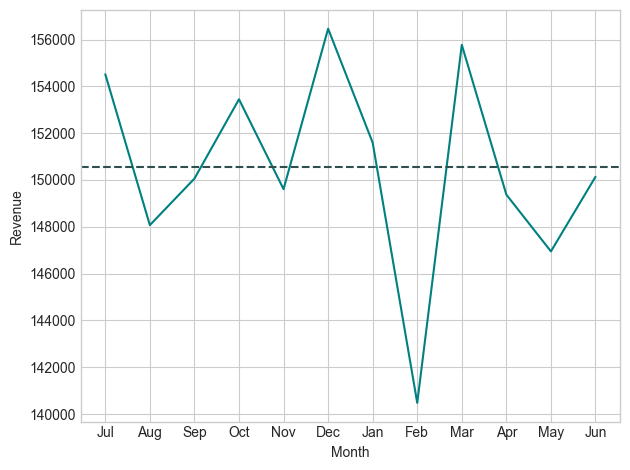

In [5]:
monthly_sales = df.groupby(df['FISCAL_MONTH']).agg(
    revenue = ('TOT_SALES','sum'),
    order_volume = ('TXN_ID','count')
    )
avg_monthly_sales = monthly_sales['revenue'].mean()

plt.plot(
    monthly_sales['revenue'],
    color='teal'
    )
plt.xticks(
    monthly_sales.index, 
    ['Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.axhline(
    avg_monthly_sales,
    linestyle='dashed',
    color='darkslategray'
    )

plt.tight_layout()
plt.show()

- Revenue spikes in December - due to Christmas  
- Decline of over 10k revenue in February

In [18]:
monthly_sales
# February has the least order volume too (19k)

month_week_sales = df.groupby([df['FISCAL_MONTH'], (df['DATE'].dt.day-1)//7+1])['TOT_SALES'].sum()
month_week_sales.xs(5, level='DATE')
# February doesn't have the sales in the last week due to lesser days in the month
# All other months are doing around ~9.9k - ~15k in the last week, this explains the february decline

FISCAL_MONTH
1     15007.5
2     14579.2
3     10275.8
4     14509.2
5      9947.8
6     14812.9
7     15045.1
9     15011.4
10    10065.6
11    15151.4
12    10286.0
Name: TOT_SALES, dtype: float64

In [7]:
segment_stats = df.groupby('PREMIUM_CUSTOMER').agg(
    customers = ('LYLTY_CARD_NBR','nunique'),
    revenue = ('TOT_SALES','sum'),
    order_volume = ('TXN_ID','count')
)
total_customers = df['LYLTY_CARD_NBR'].nunique()
total_revenue = df['TOT_SALES'].sum()
segment_stats['customers%'] = (segment_stats['customers'] / total_customers)*100
segment_stats['revenue%'] = (segment_stats['revenue'] / total_revenue)*100
segment_stats['avg_revenue_per_customer'] = (segment_stats['revenue']/segment_stats['customers'])
segment_stats

,customers,revenue,order_volume,customers%,revenue%,avg_revenue_per_customer
PREMIUM_CUSTOMER,,,,,,
Budget,24006,631406.85,86762,33.674672,34.952491,26.302043
Mainstream,28734,700865.40,95043,40.306924,38.797475,24.391501
Premium,18548,474199.45,64936,26.018404,26.250035,25.566069


Segments:
1. Mainstream is the largest. 40% of the customers, 38.8% of total revenue, order volume of almost 102k, Lowest avg revenue per customer.
    - More but low value customers
2. Budget. 33.6% of the customers, ~35% of revenue, ~93k in order volume, highest avg revenue per customer.
    - Moderate customer base but high value
3. Premium is the smallest. 26% of the customers, 26% of the revenue, 69.7% in order volume, 26.8 as average revenue per customer
    - low customer base of moderate value

<Figure size 2000x1000 with 0 Axes>

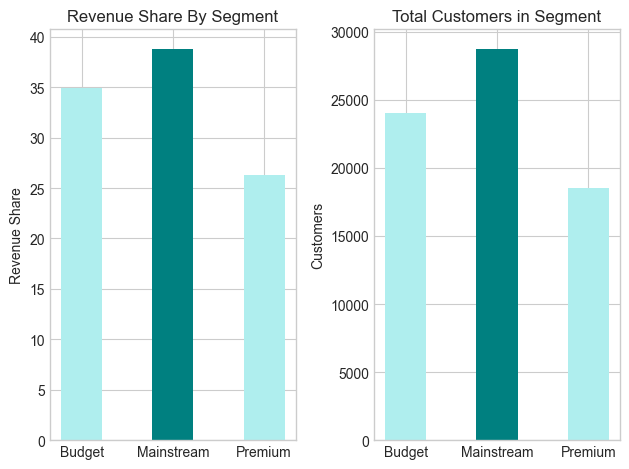

In [8]:
plt.figure(figsize=(20,10))
fix, axs = plt.subplots(1,2)

colors = [
    'teal' if bar == segment_stats['revenue%'].max() else 'paleturquoise'
    for bar in segment_stats['revenue%']
]
axs[0].bar(
    segment_stats.index, 
    segment_stats['revenue%'], 
    0.45, 
    color=colors)
axs[0].set_ylabel('Revenue Share')
axs[0].set_title('Revenue Share By Segment')

colors = [
    'teal' if bar == segment_stats['customers'].max() else 'paleturquoise'
    for bar in segment_stats['customers']
]
axs[1].bar(
    segment_stats.index,
    segment_stats['customers'],
    0.45,
    color=colors
)
axs[1].set_ylabel("Customers")
axs[1].set_title('Total Customers in Segment')

plt.tight_layout()
plt.show()

In [9]:
segment_stage_stats = df.groupby(['PREMIUM_CUSTOMER','LIFESTAGE']).agg(
    revenue = ('TOT_SALES','sum'),
    customers = ('LYLTY_CARD_NBR','nunique'),
    order_volume = ('TXN_ID','count'),
    total_quantity = ('PROD_QTY','sum')
)
segment_stage_stats['avg_units_per_customer'] = (segment_stage_stats['total_quantity'] /segment_stage_stats['customers'])
segment_stage_stats

revenue  customers  order_volume  \
PREMIUM_CUSTOMER LIFESTAGE                                                    
Budget           MIDAGE SINGLES/COUPLES   33345.70       1474          4691   
                 NEW FAMILIES             20607.45       1087          2824   
                 OLDER FAMILIES          156863.75       4611         21514   
                 OLDER SINGLES/COUPLES   127833.60       4849         17172   
                 RETIREES                105916.30       4385         14225   
                 YOUNG FAMILIES          129717.95       3953         17763   
                 YOUNG SINGLES/COUPLES    57122.10       3647          8573   
Mainstream       MIDAGE SINGLES/COUPLES   84734.25       3298         11095   
                 NEW FAMILIES             15979.70        830          2185   
                 OLDER FAMILIES           96413.55       2788         13241   
                 OLDER SINGLES/COUPLES   124648.50       4858         17061   
                 RETIREES                145168.95       6358         19970   
                 YOUNG FAMILIES           86338.25       2685         11947   
                 YOUNG SINGLES/COUPLES   147582.20       7917         19544   
Premium          MIDAGE SINGLES/COUPLES   54443.85       2369          7612   
                 NEW FAMILIES             10760.80        575          1488   
                 OLDER FAMILIES           76542.60       2232         10405   
                 OLDER SINGLES/COUPLES   123531.55       4682         16559   
                 RETIREES                 91296.65       3812         12236   
                 YOUNG FAMILIES           78571.70       2398         10784   
                 YOUNG SINGLES/COUPLES    39052.30       2480          5852   

                                         total_quantity  \
PREMIUM_CUSTOMER LIFESTAGE                                
Budget           MIDAGE SINGLES/COUPLES            8883   
                 NEW FAMILIES                      5241   
                 OLDER FAMILIES                   41853   
                 OLDER SINGLES/COUPLES            32883   
                 RETIREES                         26932   
                 YOUNG FAMILIES                   34482   
                 YOUNG SINGLES/COUPLES            15500   
Mainstream       MIDAGE SINGLES/COUPLES           21213   
                 NEW FAMILIES                      4060   
                 OLDER FAMILIES                   25804   
                 OLDER SINGLES/COUPLES            32607   
                 RETIREES                         37677   
                 YOUNG FAMILIES                   23194   
                 YOUNG SINGLES/COUPLES            36225   
Premium          MIDAGE SINGLES/COUPLES           14400   
                 NEW FAMILIES                      2769   
                 OLDER FAMILIES                   20639   
                 OLDER SINGLES/COUPLES            31693   
                 RETIREES                         23266   
                 YOUNG FAMILIES                   20901   
                 YOUNG SINGLES/COUPLES            10575   

                                         avg_units_per_customer  
PREMIUM_CUSTOMER LIFESTAGE                                       
Budget           MIDAGE SINGLES/COUPLES                6.026459  
                 NEW FAMILIES                          4.821527  
                 OLDER FAMILIES                        9.076773  
                 OLDER SINGLES/COUPLES                 6.781398  
                 RETIREES                              6.141847  
                 YOUNG FAMILIES                        8.722995  
                 YOUNG SINGLES/COUPLES                 4.250069  
Mainstream       MIDAGE SINGLES/COUPLES                6.432080  
                 NEW FAMILIES                          4.891566  
                 OLDER FAMILIES                        9.255380  
                 OLDER SINGLES/COUPLES                 6.712021  
         

<Figure size 10000x20000 with 0 Axes>

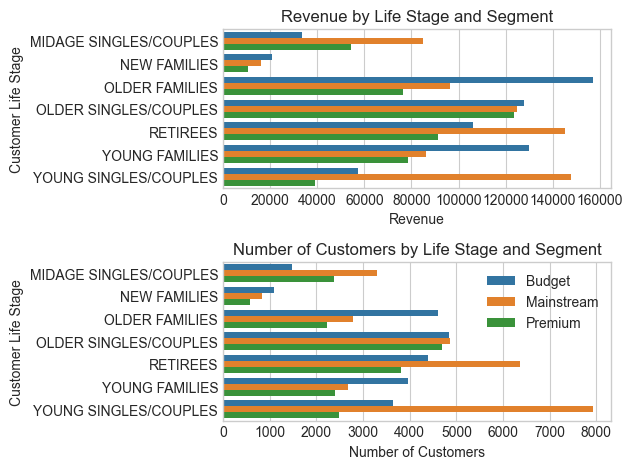

In [10]:
plt.figure(figsize=(100,200))
figure, axs = plt.subplots(2,1)

sns.barplot(
    data=segment_stage_stats, 
    y='LIFESTAGE',
    x='revenue', 
    hue='PREMIUM_CUSTOMER',
    ax = axs[0],
    legend=False
    )
axs[0].set_xlabel("Revenue")    
axs[0].set_ylabel("Customer Life Stage")
axs[0].set_title('Revenue by Life Stage and Segment')

sns.barplot(
    data=segment_stage_stats, 
    y='LIFESTAGE',
    x='customers', 
    hue='PREMIUM_CUSTOMER',
    ax = axs[1]
    )
axs[1].set_xlabel("Number of Customers")
axs[1].set_ylabel("Customer Life Stage")
axs[1].set_title('Number of Customers by Life Stage and Segment')
axs[1].legend()

plt.tight_layout()
plt.show()

- There are more Mainstream - young singles/couples and Mainstream - retirees who buy chips. This contributes to there being more revenue to these customer segments. 
- this is not the case for the Budget - Older families segment, below 5k customers and highest revenue by any life stage and segment. (Examine if it is due to the order volume)


<Figure size 2000x1000 with 0 Axes>

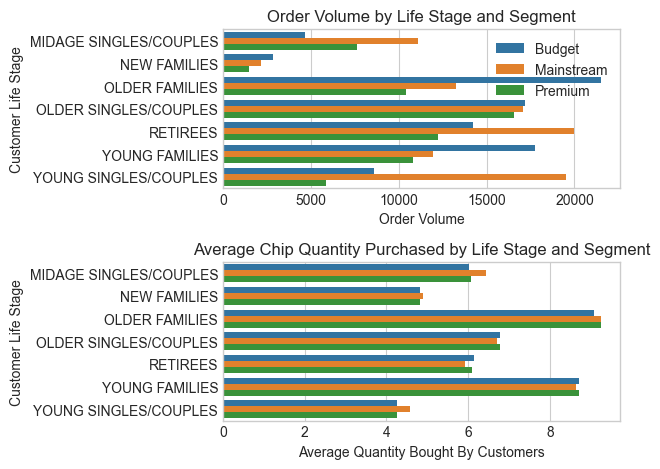

In [11]:
plt.figure(figsize=(20,10))
figure, axs = plt.subplots(2,1)

sns.barplot(
    data=segment_stage_stats, 
    y='LIFESTAGE',
    x='order_volume', 
    hue='PREMIUM_CUSTOMER',
    ax = axs[0]
    )
axs[0].set_xlabel("Order Volume")    
axs[0].set_ylabel("Customer Life Stage")
axs[0].set_title('Order Volume by Life Stage and Segment')
axs[0].legend()

sns.barplot(
    data=segment_stage_stats, 
    y='LIFESTAGE',
    x='avg_units_per_customer', 
    hue='PREMIUM_CUSTOMER',
    ax = axs[1],
    legend=False
    )
axs[1].set_xlabel("Average Quantity Bought By Customers")
axs[1].set_ylabel("Customer Life Stage")
axs[1].set_title('Average Chip Quantity Purchased by Life Stage and Segment')

plt.tight_layout()
plt.show()

- Budget - Older Families have the most orders and have puchase more chips per customer.
- Mainstream - Retires and Mainstream - Young Single/Couples have higher order volumes as well, but doesn't buy much per customer.
- Generally, Young Families and Older Families buy more chips per customer than other segments

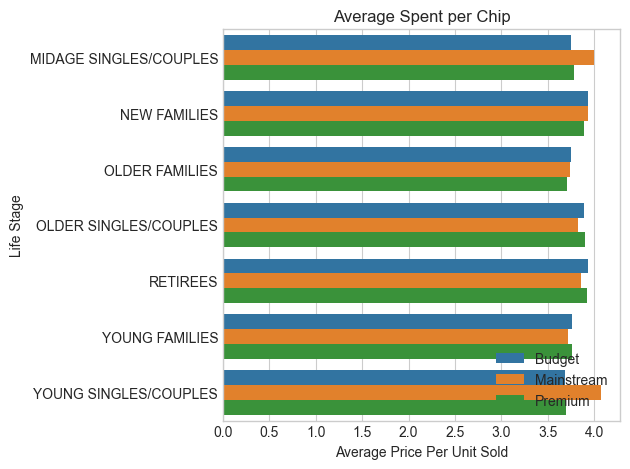

In [12]:
segment_stage_stats['avg_price_per_unit'] = segment_stage_stats['revenue'] / segment_stage_stats['total_quantity']
sns.barplot(
    data=segment_stage_stats, 
    y='LIFESTAGE',
    x='avg_price_per_unit', 
    hue='PREMIUM_CUSTOMER'
    )
plt.xlabel('Average Price Per Unit Sold')
plt.ylabel('Life Stage')
plt.title('Average Spent per Chip')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

- Midstream - Young Singles/Couples and Midstream - Midage Singles/Couples are paying more per packet of chip compared to their Budget and Premium.

In [13]:
# Run an ANOVA test to check if that Midstream Young Singles/Couples spike is statistically significant
test_df = df.copy()
test_df['Unit_price'] = test_df['TOT_SALES'] / test_df['PROD_QTY']

young_sc = test_df.loc[df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES']

Budget = young_sc.loc[young_sc['PREMIUM_CUSTOMER'] == 'Budget', 'Unit_price']
Mainstream = young_sc.loc[young_sc['PREMIUM_CUSTOMER'] == 'Mainstream', 'Unit_price']
Premium = young_sc.loc[young_sc['PREMIUM_CUSTOMER'] == 'Premium', 'Unit_price']

stats.f_oneway(Budget, Mainstream, Premium)

F_onewayResult(statistic=np.float64(624.5194054720616), pvalue=np.float64(4.391372641744783e-267))

- pvalue = 4.39e-267 (essentially zero), the difference in avg spent per chip packet for Mainstream - Young Singles/Couples is extremely significant than Budget or Premium - Young Singles/Couples.

- Mainstream - Young Singles/Couples purchasing behavior

In [14]:
# Affinity Analysis
mask_lifestage = (df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (df['PREMIUM_CUSTOMER'] == 'Mainstream')
segment1 = df[mask_lifestage]
other = df[~mask_lifestage]

seg1_quantity = df[mask_lifestage]['PROD_QTY'].sum()
oth_quantity = df[~mask_lifestage]['PROD_QTY'].sum()

seg1_brand = df[mask_lifestage].groupby('BRAND_NAME')['PROD_QTY'].sum() / seg1_quantity
oth_brand = df[~mask_lifestage].groupby('BRAND_NAME')['PROD_QTY'].sum() / oth_quantity

(seg1_brand / oth_brand).sort_values(ascending=False)

BRAND_NAME
Tyrrells          1.229221
Twisties          1.220437
Doritos           1.204685
Kettle            1.196993
Tostitos          1.196809
Pringles          1.187758
Cobs Popd         1.144172
Infuzions         1.134474
Thins             1.060394
Grain Waves       1.049835
Cheezels          0.964637
Smiths            0.774273
FFPC              0.686198
Cheetos           0.666343
Red Rock Deli     0.649686
Natural ChipCo    0.635823
CCs               0.592220
Sunbites          0.505161
Woolworths        0.488020
BR                0.444003
Name: PROD_QTY, dtype: float64

- Mainstream young singles/couples are 23% more likely to purchase Tyrrells chips compared to the
rest of the population
- Mainstream young singles/couples are 56% less likely to purchase Burger Rings compared to the rest
of the population

In [15]:
seg1_pack = df[mask_lifestage].groupby('PACK_SIZE')['PROD_QTY'].sum() / seg1_quantity
oth_pack = df[~mask_lifestage].groupby('PACK_SIZE')['PROD_QTY'].sum() / oth_quantity

(seg1_pack / oth_pack).sort_values(ascending=False)

PACK_SIZE
270    1.269450
330    1.222836
380    1.214449
134    1.187758
110    1.184722
210    1.160381
135    1.130546
250    1.124196
170    0.998284
150    0.965256
175    0.945264
165    0.894577
190    0.601822
180    0.592081
160    0.518090
90     0.505161
125    0.498899
200    0.481340
70     0.480733
220    0.444003
Name: PROD_QTY, dtype: float64

- It looks like Mainstream young singles/couples are 27% more likely to purchase a 270g pack of chips compared to the rest of the population  
Dive into what brands sell this pack size.

In [16]:
df[df['PACK_SIZE'] == 270]['BRAND_NAME'].unique()
# Twisties are the only brand offering 270g packs and so this may instead be reflecting a higher likelihood of purchasing Twisties.

array(['Twisties'], dtype=object)

#### Findings
- Sales have mainly been due to Budget - older families, Mainstream - young singles/couples, and Mainstream
- retirees shoppers. We found that the high spend in chips for mainstream young singles/couples and retirees is due to there being more of them than other buyers. Mainstream, midage and young singles and couples are also more likely to pay more per packet of chips. This is indicative of impulse buying behaviour.
- Mainstream young singles and couples are 23% more likely to purchase Tyrrells chips compared to the rest of the population.

**Recommendation:**
- Sales are concentrated in three key groups: Budget - Older Families, Mainstream - Young Singles/Couples, and Mainstream - Retirees. Since the high spend from Mainstream Young Singles/Couples and Retirees comes from their larger population rather than higher individual spend, retention and acquisition efforts targeting these groups will deliver the strongest revenue impact.
- Within Mainstream Young Singles/Couples, the confirmed willingness to pay a premium per packet, combined with a clear affinity for premium brands like Tyrrells, makes this group well suited to premium product placement, targeted promotions, and new premium SKU launches rather than discount-driven campaigns.
- Budget - Older Families should also receive dedicated attention despite the "Budget" label - their high order volume and units purchased per customer make them a high-revenue lifestage, best retained through bulk-pack or family-size offers rather than price discounting.